### Import libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import f_oneway, kruskal
from statsmodels.stats.multicomp import pairwise_tukeyhsd

In [3]:
df = pd.read_csv('../data/processed/retail_cleaned.csv')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Product Name,Sales,Year,Month,Month_Name,Quarter,Year_Month,Day,Day_of_Week,Shipping_Days
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Bush Somerset Collection Bookcase,261.9600,2017,11,November,4,2017-11,8,Wednesday,3
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,2017,11,November,4,2017-11,8,Wednesday,3
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Self-Adhesive Address Labels for Typewriters b...,14.6200,2017,6,June,2,2017-06,12,Monday,4
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Bretford CR4500 Series Slim Rectangular Table,957.5775,2016,10,October,4,2016-10,11,Tuesday,7
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Eldon Fold 'N Roll Cart System,22.3680,2016,10,October,4,2016-10,11,Tuesday,7


### Sales by region

In [4]:
region_summary = (
    df.groupby("Region")["Sales"]
    .agg(["count", "mean", "median", "std", "sum"])
    .sort_values("mean", ascending=False))
region_summary

,count,mean,median,std,sum
Region,,,,,
South,1598,243.524067,54.114,779.850548,389151.4590
East,2785,240.401697,54.960,626.366105,669518.7260
West,3140,226.184613,61.002,524.240789,710219.6845
Central,2277,216.357889,45.920,636.040148,492646.9132


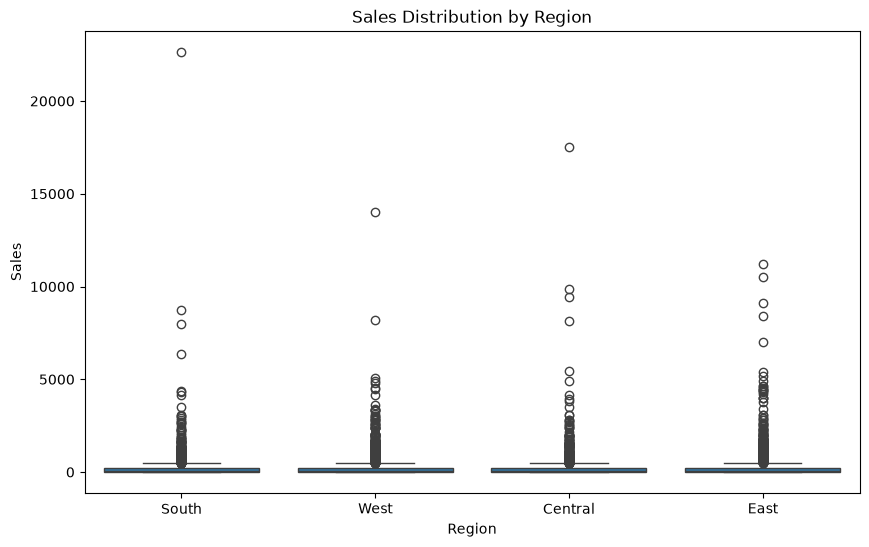

In [5]:
plt.figure(figsize=(10, 6))

sns.boxplot(data=df,x='Region',y='Sales')

plt.title('Sales Distribution by Region')
plt.xlabel('Region')
plt.ylabel('Sales')

plt.show()

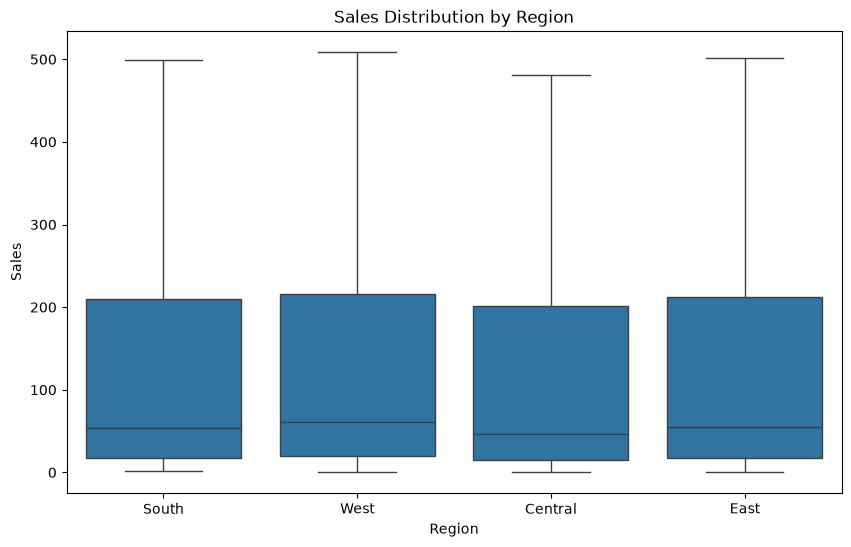

In [6]:
plt.figure(figsize=(10, 6))

sns.boxplot(data=df,x='Region',y='Sales',showfliers=False)

plt.title('Sales Distribution by Region')
plt.xlabel('Region')
plt.ylabel('Sales')

plt.show()

### One way ANOVA

In [7]:
east = df.loc[df['Region'] == 'East', 'Sales']
west = df.loc[df['Region'] == 'West', 'Sales']
central = df.loc[df['Region'] == 'Central', 'Sales']
south = df.loc[df['Region'] == 'South', 'Sales']

In [8]:
f_stat, p_value = f_oneway(east,west,central,south)
print('F-statistic:', f_stat)
print('p-value:', p_value)

F-statistic: 0.897432230784499
p-value: 0.44157758889611065


### Interpret the p-value

In [9]:
alpha = 0.05

if p_value < alpha:
    print('Reject H0')
    print('There is a statistically significant difference in mean sales.')
else:
    print('Fail to reject H0')
    print('There is not enough evidence of a statistically significant difference.')

Fail to reject H0
There is not enough evidence of a statistically significant difference.


In [10]:
df.groupby('Region')['Sales'].var()

Region
Central    404547.069479
East       392334.497077
South      608166.877954
West       274828.404960
Name: Sales, dtype: float64

In [11]:
df.groupby('Region')['Sales'].std()

Region
Central    636.040148
East       626.366105
South      779.850548
West       524.240789
Name: Sales, dtype: float64

### Normality

In [20]:
for region in df["Region"].unique():
    sample = df.loc[df["Region"] == region, "Sales"]
    
    statistic, p = stats.shapiro(
        sample.sample(
            min(5000, len(sample)),
            random_state=42
        )
    )
    
    print(region)
    print("Statistic:", statistic)
    print("p-value:", p,"\n")

South
Statistic: 0.24985405638291813
p-value: 2.711870433991328e-62 

West
Statistic: 0.3982772040927375
p-value: 4.890511201537185e-73 

Central
Statistic: 0.28763609299490855
p-value: 4.626797732930719e-69 

East
Statistic: 0.3569738664908474
p-value: 1.299124810803462e-71 



### Check Variance equality

In [13]:
levene_stat, levene_p=stats.levene(
    east,
    west,
    central,
    south
)
print('Levene statistic:', levene_stat)
print('p-value',levene_p)

Levene statistic: 0.8139362780690771
p-value 0.48593241296925915


### Kruskal-Wallis

In [14]:
h_stat, kruskal_p = kruskal(
    east,
    west,
    central,
    south
)

print("Kruskal-Wallis statistic:", h_stat)
print("p-value:", kruskal_p)

Kruskal-Wallis statistic: 25.2469082946559
p-value: 1.3709685721875768e-05


### Pairwise analysis

In [15]:
tukey = pairwise_tukeyhsd(
    endog=df["Sales"],
    groups=df["Region"],
    alpha=0.05
)

print(tukey)

 Multiple Comparison of Means - Tukey HSD, FWER=0.05  
 group1 group2 meandiff p-adj   lower    upper  reject
------------------------------------------------------
Central   East  24.0438 0.5259 -21.4491 69.5368  False
Central  South  27.1662 0.5448 -25.3802 79.7126  False
Central   West   9.8267 0.9411 -34.4943 54.1478  False
   East  South   3.1224 0.9986 -47.4091 53.6538  False
   East   West -14.2171 0.8196 -56.1296 27.6955  False
  South   West -17.3395 0.8046 -66.8185 32.1396  False
------------------------------------------------------


### Statistical Summary

In [16]:
statistical_summary = {
    "ANOVA_F": f_stat,
    "ANOVA_p": p_value,
    "Levene_p": levene_p,
    "Kruskal_H": h_stat,
    "Kruskal_p": kruskal_p
}

statistical_summary

{'ANOVA_F': np.float64(0.897432230784499),
 'ANOVA_p': np.float64(0.44157758889611065),
 'Levene_p': np.float64(0.48593241296925915),
 'Kruskal_H': np.float64(25.2469082946559),
 'Kruskal_p': np.float64(1.3709685721875768e-05)}

In [17]:
consumer = df.loc[
    df["Segment"] == "Consumer",
    "Sales"
]

corporate = df.loc[
    df["Segment"] == "Corporate",
    "Sales"
]

home_office = df.loc[
    df["Segment"] == "Home Office",
    "Sales"
]

In [18]:
f_segment, p_segment = f_oneway(
    consumer,
    corporate,
    home_office
)

print("F-statistic:", f_segment)
print("p-value:", p_segment)

F-statistic: 0.5874032714436911
p-value: 0.5557881652682072


In [19]:
h_segment, p_segment_kw = kruskal(
    consumer,
    corporate,
    home_office
)

print("Kruskal-Wallis statistic:", h_segment)
print("p-value:", p_segment_kw)

Kruskal-Wallis statistic: 0.43937522529886164
p-value: 0.8027695338448759


## Statistical Conclusion

### Research Question

Is there a statistically significant difference in sales across regions?

### Hypotheses

**H₀:** Mean sales are equal across all regions.

**H₁:** At least one region has a different mean sales value.

### Significance Level

α = 0.05

### Tests Used

- One-way ANOVA
- Levene's test for variance equality
- Kruskal-Wallis test as a non-parametric robustness check
- Tukey HSD for post-hoc pairwise comparisons when appropriate

### Interpretation

The statistical tests were used to determine whether the observed regional differences in sales are likely to represent genuine differences rather than random variation.